In [23]:
import pandas as pd
import numpy as np
path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/laptop_pricing_dataset_mod2.csv"
df = pd.read_csv(path, header=0)
print(df.head())

   Unnamed: 0.1  Unnamed: 0 Manufacturer  Category  GPU  OS  CPU_core  \
0             0           0         Acer         4    2   1         5   
1             1           1         Dell         3    1   1         3   
2             2           2         Dell         3    1   1         7   
3             3           3         Dell         4    2   1         5   
4             4           4           HP         4    2   1         7   

   Screen_Size_inch  CPU_frequency  RAM_GB  Storage_GB_SSD  Weight_pounds  \
0              14.0       0.551724       8             256        3.52800   
1              15.6       0.689655       4             256        4.85100   
2              15.6       0.931034       8             256        4.85100   
3              13.3       0.551724       8             128        2.69010   
4              15.6       0.620690       8             256        4.21155   

   Price Price-binned  Screen-Full_HD  Screen-IPS_panel  
0    978          Low               0   

In [24]:
from sklearn.linear_model import LinearRegression
X= df[['CPU_frequency']]
y= df[['Price']]
lm = LinearRegression()
lm.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [25]:
print("Coefficient (pente) :", lm.coef_)
print("Intercept :", lm.intercept_)
# Price = a x CPU_frequency + B 
# Price = 1485.19 x 2,5 + 253.66117069
# donc Prix = 3966


Coefficient (pente) : [[1485.19362648]]
Intercept : [253.66117069]


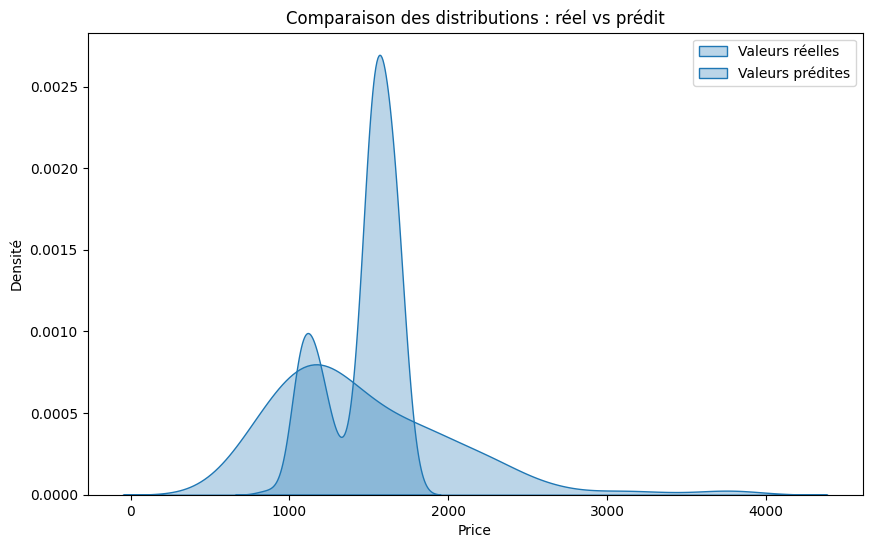

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

yhat = lm.predict(X)

plt.figure(figsize=(10,6))

sns.kdeplot(y, color="blue", label="Valeurs réelles", fill=True, alpha=0.3 )
sns.kdeplot(yhat, color="red", label="Valeurs prédites",fill=True, alpha=0.3)

plt.xlabel("Price")
plt.ylabel("Densité")
plt.title("Comparaison des distributions : réel vs prédit")
plt.legend()

plt.show()

In [27]:
# Price=a1​X1​+a2​X2​+...+an​Xn​+b
X = df[[
    'CPU_frequency',
    'RAM_GB',
    'Storage_GB_SSD',
    'CPU_core',
    'OS',
    'GPU',
    'Category'
]]

y = df['Price']

In [28]:
from sklearn.linear_model import LinearRegression

lm_multi = LinearRegression()
lm_multi.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [29]:
yhat_multi = lm_multi.predict(X)

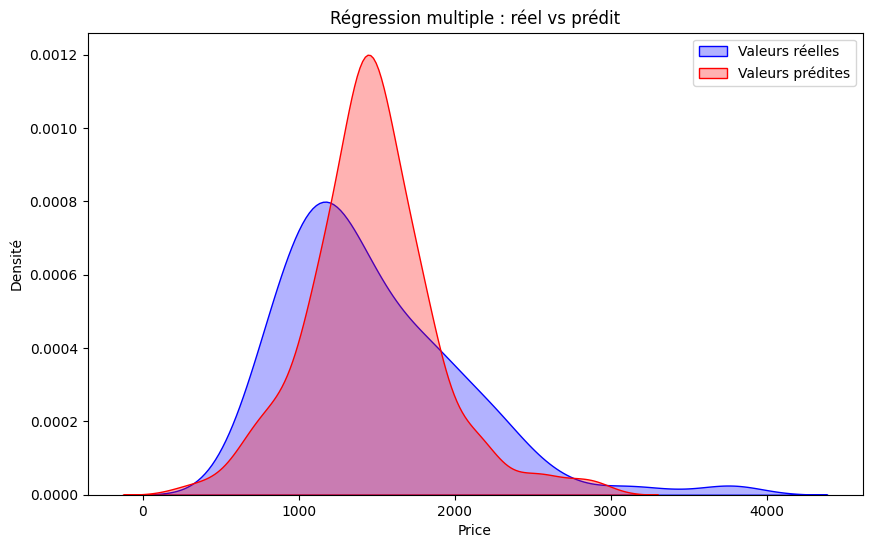

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.kdeplot(y, color="blue", label="Valeurs réelles", fill=True, alpha=0.3)
sns.kdeplot(yhat_multi, color="red", label="Valeurs prédites", fill=True, alpha=0.3)

plt.xlabel("Price")
plt.ylabel("Densité")
plt.title("Régression multiple : réel vs prédit")
plt.legend()

plt.show()

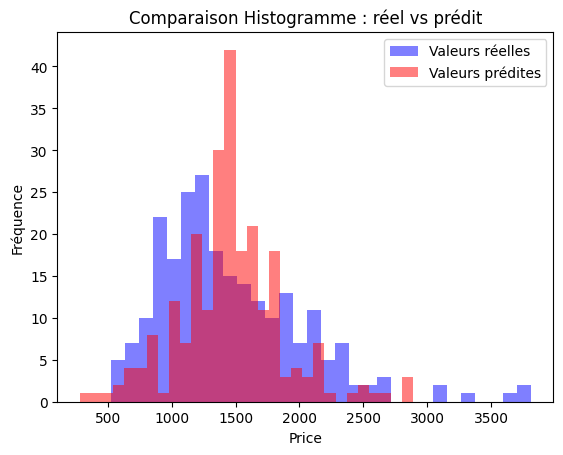

In [31]:
import matplotlib.pyplot as plt

# Histogramme des valeurs réelles
plt.hist(y, bins=30, alpha=0.5, color='blue', label='Valeurs réelles')

# Histogramme des valeurs prédites
plt.hist(yhat_multi, bins=30, alpha=0.5, color='red', label='Valeurs prédites')

plt.xlabel("Price")
plt.ylabel("Fréquence")
plt.title("Comparaison Histogramme : réel vs prédit")
plt.legend()

plt.show()